<a href="https://colab.research.google.com/github/waleedahmed0253/CICMalDroid/blob/main/CICMalDroid__(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1.Environment Set Up

##1.1 Installing Libraires

In [1]:
#!pip install pandas scikit-learn numpy matplotlib -U gdown

##1.2 Importing Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from collections import Counter
import pprint
from datetime import date
from IPython.display import display
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay, roc_curve,
    auc, precision_recall_curve, precision_recall_fscore_support
)
from scipy.stats import ttest_rel, wilcoxon
import joblib
import gdown
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

print("Environment setup complete — all libraries impoted successfully")


Environment setup complete — all libraries impoted successfully


#2.Dataset Loading & Exploration

##2.1 Data Loading

In [3]:
file_id = '1CUNdHFe_dzqAK-jAeW0l6JRJZZMrDrHO'
gdown.download(f'https://drive.google.com/uc?id={file_id}', 'CICMalDroidDataset.csv', quiet=False)

df = pd.read_csv('CICMalDroidDataset.csv')

Downloading...
From: https://drive.google.com/uc?id=1CUNdHFe_dzqAK-jAeW0l6JRJZZMrDrHO
To: /content/CICMalDroidDataset.csv
100%|██████████| 11.7M/11.7M [00:00<00:00, 68.5MB/s]


##2.2 Dataset Dimensions

In [4]:
print("(Rows, Columns):", df.shape)

(Rows, Columns): (11598, 471)


##2.3 Column Names

In [5]:
print(df.columns.tolist())

['ACCESS_PERSONAL_INFO___', 'ALTER_PHONE_STATE___', 'ANTI_DEBUG_____', 'CREATE_FOLDER_____', 'CREATE_PROCESS`_____', 'CREATE_THREAD_____', 'DEVICE_ACCESS_____', 'EXECUTE_____', 'FS_ACCESS____', 'FS_ACCESS()____', 'FS_ACCESS(CREATE)____', 'FS_ACCESS(CREATE__APPEND)__', 'FS_ACCESS(CREATE__READ)__', 'FS_ACCESS(CREATE__READ__WRITE)', 'FS_ACCESS(CREATE__WRITE)__', 'FS_ACCESS(CREATE__WRITE__APPEND)', 'FS_ACCESS(READ)____', 'FS_ACCESS(READ__WRITE)__', 'FS_ACCESS(WRITE)____', 'FS_PIPE_ACCESS___', 'FS_PIPE_ACCESS()___', 'FS_PIPE_ACCESS(READ)___', 'FS_PIPE_ACCESS(READ__)_', 'FS_PIPE_ACCESS(READ__WRITE)_', 'FS_PIPE_ACCESS(WRITE)___', 'NETWORK_ACCESS____', 'NETWORK_ACCESS()____', 'NETWORK_ACCESS(READ)____', 'NETWORK_ACCESS(READ__WRITE)__', 'NETWORK_ACCESS(READ__WRITE__)', 'NETWORK_ACCESS(WRITE)____', 'NETWORK_ACCESS(WRITE__)__', 'SMS_SEND____', 'TERMINATE_PROCESS', 'TERMINATE_THREAD', '__arm_nr_cacheflush', '__arm_nr_set_tls', '_llseek', '_newselect', 'accept', 'access', 'add', 'addAccessibilityIn

##2.4 Columns Datatype

In [6]:
column_dtypes = df.dtypes.to_frame(name='DataType')
column_dtypes.reset_index(inplace=True)
column_dtypes.columns = ['Column', 'DataType']
display(column_dtypes)

,Column,DataType
0,ACCESS_PERSONAL_INFO___,int64
1,ALTER_PHONE_STATE___,int64
2,ANTI_DEBUG_____,int64
3,CREATE_FOLDER_____,int64
4,CREATE_PROCESS`_____,int64
...,...,...
466,watchRotation,int64
467,windowGainedFocus,int64
468,write,int64
469,writev,int64


##2.5 Dataset Structure

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11598 entries, 0 to 11597
Columns: 471 entries, ACCESS_PERSONAL_INFO___ to Class
dtypes: int64(471)
memory usage: 41.7 MB


##2.6 First 5 Rows of Dataset

In [8]:
display(df.head())

,ACCESS_PERSONAL_INFO___,ALTER_PHONE_STATE___,ANTI_DEBUG_____,CREATE_FOLDER_____,CREATE_PROCESS`_____,CREATE_THREAD_____,DEVICE_ACCESS_____,EXECUTE_____,FS_ACCESS____,FS_ACCESS()____,...,utimes,vfork,vibrate,vibratePattern,wait4,watchRotation,windowGainedFocus,write,writev,Class
0,1,0,0,3,0,14,2,0,3,0,...,0,0,0,0,0,0,0,37,10,1
1,3,0,0,6,0,42,91,0,32,0,...,0,0,0,0,0,0,2,2838,46,1
2,2,0,0,4,0,23,3,0,17,2,...,0,0,0,0,0,0,1,111,20,1
3,1,0,0,4,0,27,9,0,36,0,...,0,0,0,0,0,0,7,987,197,1
4,3,0,0,11,0,18,3,0,16,0,...,0,0,0,0,0,0,1,98,25,1


##2.6 Last 5 Rows of Dataset

In [9]:
display(df.tail())

,ACCESS_PERSONAL_INFO___,ALTER_PHONE_STATE___,ANTI_DEBUG_____,CREATE_FOLDER_____,CREATE_PROCESS`_____,CREATE_THREAD_____,DEVICE_ACCESS_____,EXECUTE_____,FS_ACCESS____,FS_ACCESS()____,...,utimes,vfork,vibrate,vibratePattern,wait4,watchRotation,windowGainedFocus,write,writev,Class
11593,2,0,0,11,0,61,13,0,66,17,...,0,0,0,0,0,0,10,2764,236,5
11594,6,0,0,10,1,69,50,1,118,15,...,0,0,0,0,1,0,5,4417,295,5
11595,0,0,0,0,0,21,16,0,48,9,...,0,0,0,0,0,0,5,241,67,5
11596,1,0,0,15,0,90,80,0,239,50,...,0,0,0,0,0,0,3,1703,774,5
11597,0,0,0,10,0,47,6,0,44,11,...,0,0,0,0,0,0,13,3102,186,5


#3.Exploratory Data Analysis (EDA) Summary Statistics

In [10]:
pd.set_option('display.max_columns', None)
summary_stats = df.describe()
summary_stats

,ACCESS_PERSONAL_INFO___,ALTER_PHONE_STATE___,ANTI_DEBUG_____,CREATE_FOLDER_____,CREATE_PROCESS`_____,CREATE_THREAD_____,DEVICE_ACCESS_____,EXECUTE_____,FS_ACCESS____,FS_ACCESS()____,FS_ACCESS(CREATE)____,FS_ACCESS(CREATE__APPEND)__,FS_ACCESS(CREATE__READ)__,FS_ACCESS(CREATE__READ__WRITE),FS_ACCESS(CREATE__WRITE)__,FS_ACCESS(CREATE__WRITE__APPEND),FS_ACCESS(READ)____,FS_ACCESS(READ__WRITE)__,FS_ACCESS(WRITE)____,FS_PIPE_ACCESS___,FS_PIPE_ACCESS()___,FS_PIPE_ACCESS(READ)___,FS_PIPE_ACCESS(READ__)_,FS_PIPE_ACCESS(READ__WRITE)_,FS_PIPE_ACCESS(WRITE)___,NETWORK_ACCESS____,NETWORK_ACCESS()____,NETWORK_ACCESS(READ)____,NETWORK_ACCESS(READ__WRITE)__,NETWORK_ACCESS(READ__WRITE__),NETWORK_ACCESS(WRITE)____,NETWORK_ACCESS(WRITE__)__,SMS_SEND____,TERMINATE_PROCESS,TERMINATE_THREAD,__arm_nr_cacheflush,__arm_nr_set_tls,_llseek,_newselect,accept,access,add,addAccessibilityInteractionConnection,addAccountExplicitly,addClient,addPeriodicSync,addStatusChangeListener,addToDisplay,addToDisplayWithoutInputChannel,addWithoutInputChannel,attachEngine,beginRestoreSession,bind,brk,cancelAllNotifications,cancelNotificationWithTag,cancelSync,cancelToast,cancelVibrate,capset,chdir,checkOperation,checkPackage,checkPermission,checkSignatures,chmod,chown32,clock_getres,clock_gettime,clone,close,collapsePanels,connect,currentToCanonicalPackageNames,dataChanged,deleteHost,disconnect,displayCompletions,dup,dup2,endRestoreSession,engineShown,enqueueNotificationWithTag,enqueueToast,epoll_create,epoll_ctl,epoll_wait,eventfd2,execve,exit,exit_group,faccessat,fchmod,fchown32,fcntl,fcntl64,fdatasync,finishDrawing,finishInput,finishSpellCheckerService,flock,fork,fstat64,fstatfs64,fsync,ftruncate,ftruncate64,futex,geocoderIsPresent,getAccounts,getAccountsAsUser,getActiveAdmins,getActiveNetworkInfo,getActivePhoneType,getActivityInfo,getAllCellInfo,getAllNetworkInfo,getAllPkgUsageStats,getAllProviders,getAnimationScale,getAppWidgetIds,getAppWidgetInfo,getApplicationEnabledSetting,getApplicationInfo,getApplicationRestrictions,getAuthenticatorTypes,getBestProvider,getBoolean,getCallState,getCameraDisabled,getCameraInfo,getCellLocation,getClientDefaultLanguage,getComponentEnabledSetting,getConfiguredNetworks,getConnectionInfo,getCurrentInputMethodSubtype,getCurrentModeType,getCurrentSpellChecker,getCurrentSpellCheckerSubtype,getDataActivity,getDataNetworkType,getDataState,getDeviceId,getDeviceList,getDeviceOwner,getDeviceSvn,getDhcpInfo,getDisplayFrame,getDisplayIds,getDisplayInfo,getEnabledAccessibilityServiceList,getEnabledInputMethodList,getEnabledInputMethodSubtypeList,getFlashlightEnabled,getFromLocation,getGlobalSearchActivity,getGroupIdLevel1,getHeightHint,getIccSerialNumber,getInTouchMode,getInputDevice,getInputDeviceIds,getInputMethodList,getInstallLocation,getInstalledApplications,getInstalledPackages,getInstalledProviders,getInstallerPackageName,getIsSyncable,getLastChosenActivity,getLastInputMethodSubtype,getLastLocation,getLine1Number,getLong,getMasterSyncAutomatically,getMessenger,getMobileDataEnabled,getMobileIfaces,getMode,getNameForUid,getNeighboringCellInfo,getNetworkInfo,getNetworkPreference,getNightMode,getNumberOfCameras,getPackageGids,getPackageInfo,getPackageSizeInfo,getPackagesForUid,getPassword,getPermissionGroupInfo,getPermissionInfo,getPreferredActivities,getPreferredPackages,getPrimaryClip,getProviderInfo,getProviderProperties,getProviders,getProxy,getReceiverInfo,getRingerMode,getRingtonePlayer,getScanResults,getSearchableInfo,getSearchablesInGlobalSearch,getServiceInfo,getSpellCheckerService,getState,getStorageEncryptionStatus,getStreamMaxVolume,getStreamVolume,getString,getSubscriberId,getSyncAutomatically,getSystemAvailableFeatures,getSystemSharedLibraryNames,getTetheredIfaces,getUserData,getUserIcon,getUserRestrictions,getUserSerialNumber,getUsers,getVibrateSetting,getVoiceMailAlphaTag,getVoiceMailNumber,getWallpaper,getWallpaperInfo,getWidthHint,getWifiApConfiguration,getWifiApEnabledState,getWifiDisplayStatus,getWifiEnabledState,getWifiS

#4.Data Visualizations

##4.1 Class Distribution Plot

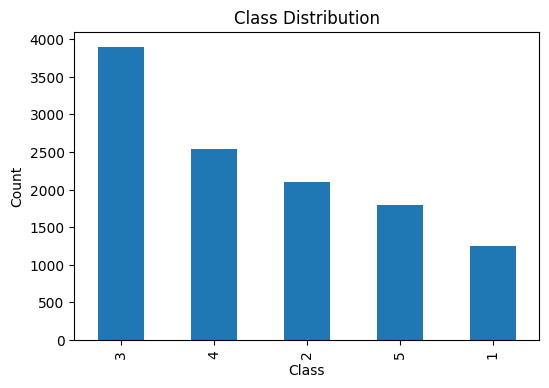

,Count,count
0,3,3904
1,4,2546
2,2,2100
3,5,1795
4,1,1253


In [11]:
plt.figure(figsize=(6,4))
counts = df['Class'].value_counts()
counts.plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()
display(pd.DataFrame(counts).reset_index().rename(columns={'index':'Class', 'Class':'Count'}))


##4.2 Correlation Heatmap (Top 20 Most Variable Features)

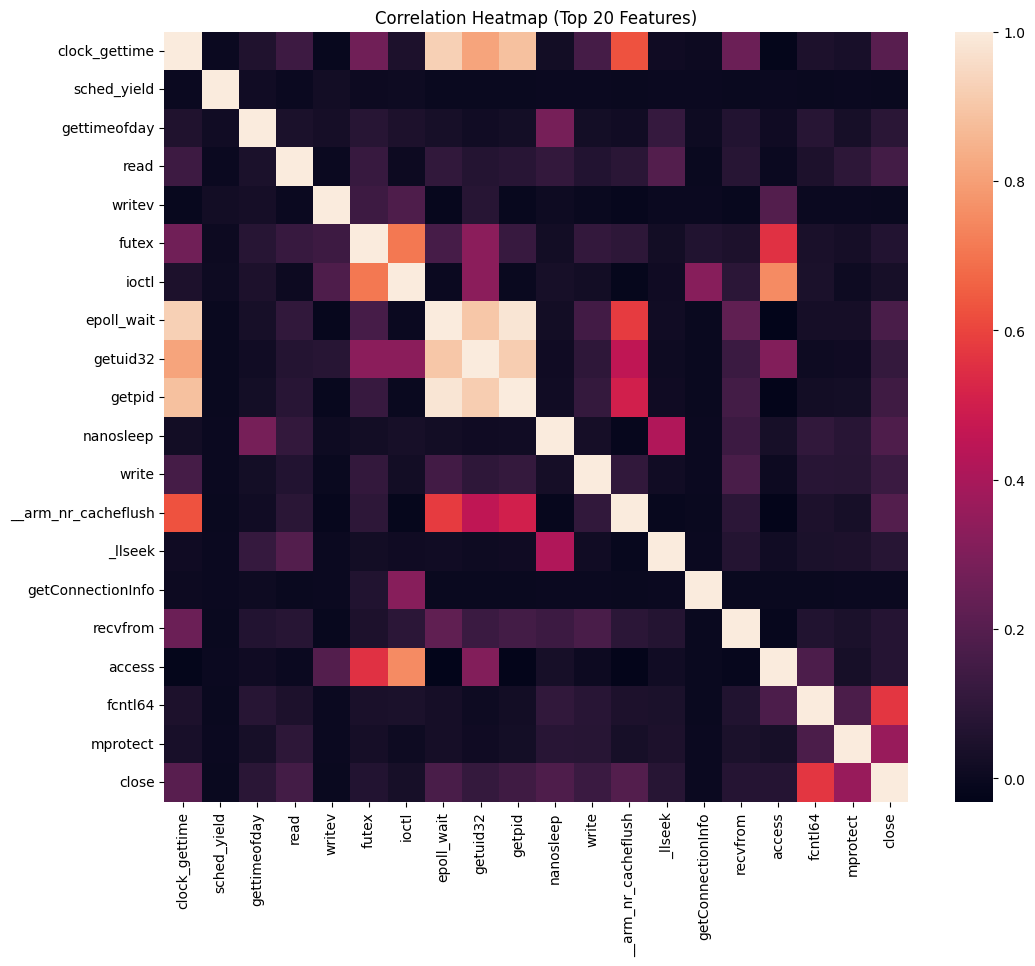

,clock_gettime,sched_yield,gettimeofday,read,writev,futex,ioctl,epoll_wait,getuid32,getpid,nanosleep,write,__arm_nr_cacheflush,_llseek,getConnectionInfo,recvfrom,access,fcntl64,mprotect,close
clock_gettime,1.000000,-0.001750,0.056168,0.136424,-0.007177,0.264002,0.048705,0.925669,0.812863,0.885857,0.019374,0.157452,0.626645,0.013076,0.002123,0.251614,-0.021004,0.046072,0.037492,0.204149
sched_yield,-0.001750,1.000000,0.016269,-0.002418,0.017430,0.001759,0.005916,-0.004414,-0.004190,-0.003672,-0.000741,-0.001911,-0.003737,-0.000989,-0.000403,-0.003349,-0.001720,-0.003110,-0.001915,-0.003923
gettimeofday,0.056168,0.016269,1.000000,0.043560,0.028556,0.075157,0.046169,0.030801,0.016467,0.021801,0.279716,0.021783,0.015180,0.115411,0.006579,0.062634,0.011137,0.075013,0.031588,0.082139
read,0.136424,-0.002418,0.043560,1.000000,-0.000623,0.121341,0.003195,0.103174,0.066162,0.078112,0.107522,0.065001,0.084140,0.191505,-0.003206,0.074226,0.000102,0.046634,0.092530,0.153877
writev,-0.007177,0.017430,0.028556,-0.000623,1.000000,0.135314,0.181832,-0.012849,0.074538,-0.010748,0.007748,-0.004491,-0.012101,0.000711,-0.001304,-0.010160,0.192848,-0.002775,-0.001069,-0.005064
futex,0.264002,0.001759,0.075157,0.121341,0.135314,1.000000,0.706300,0.158856,0.328184,0.118519,0.020657,0.107992,0.090658,0.017432,0.058192,0.045984,0.555728,0.038643,0.029360,0.064886
ioctl,0.048705,0.005916,0.046169,0.003195,0.181832,0.706300,1.000000,0.000183,0.327953,-0.003299,0.031480,0.018214,-0.017091,0.010476,0.319793,0.089290,0.753378,0.042784,0.007755,0.032572
epoll_wait,0.925669,-0.004414,0.030801,0.103174,-0.012849,0.158856,0.000183,1.000000,0.900120,0.982426,0.021338,0.147119,0.579185,0.013553,-0.006535,0.223371,-0.030966,0.027752,0.026068,0.166969
getuid32,0.812863,-0.004190,0.016467,0.066162,0.074538,0.328184,0.327953,0.900120,1.000000,0.918972,0.011145,0.097539,0.456241,0.006024,-0.006671,0.129616,0.309707,0.006802,0.010824,0.113097
getpid,0.885857,-0.003672,0.021801,0.078112,-0.010748,0.118519,-0.003299,0.982426,0.918972,1.000000,0.013710,0.110869,0.504491,0.010127,-0.005591,0.153611,-0.025396,0.020596,0.024395,0.139975


In [12]:
top20 = df.var().sort_values(ascending=False).head(20).index
plt.figure(figsize=(12,10))
sns.heatmap(df[top20].corr(), annot=False)
plt.title('Correlation Heatmap (Top 20 Features)')
plt.show()
display(df[top20].corr())

##4.3 Top 20 Most Frequent API/System Call Features

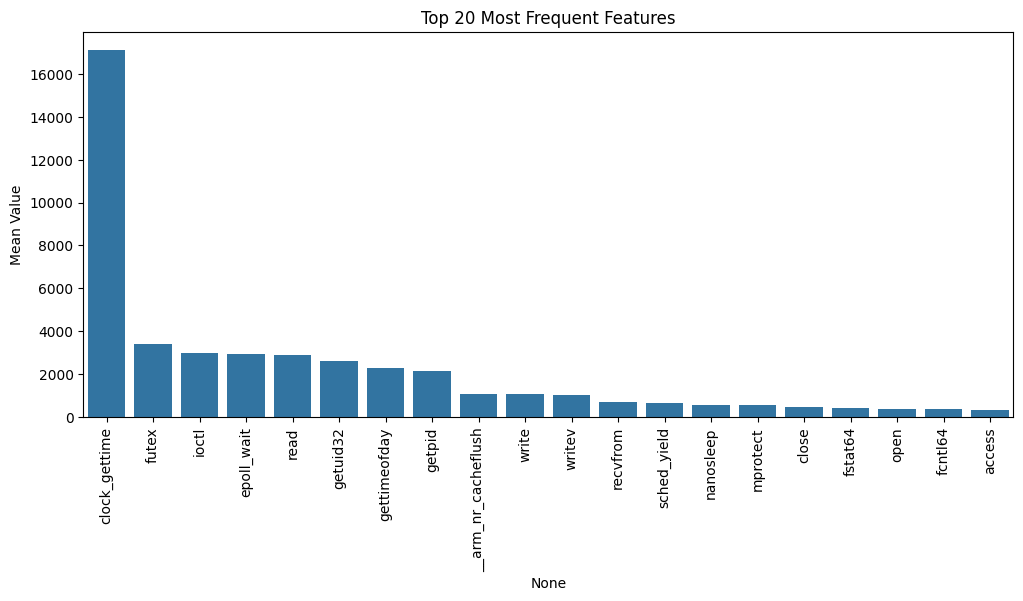

,Feature,Mean Value
0,clock_gettime,17103.524573
1,futex,3403.121659
2,ioctl,3003.004915
3,epoll_wait,2959.879290
4,read,2882.256165
5,getuid32,2630.008277
6,gettimeofday,2297.242283
7,getpid,2151.317727
8,__arm_nr_cacheflush,1083.033885
9,write,1071.197362


In [13]:
freq = df.drop('Class', axis=1).mean().sort_values(ascending=False).head(20)
plt.figure(figsize=(12,5))
sns.barplot(x=freq.index, y=freq.values)
plt.xticks(rotation=90)
plt.title('Top 20 Most Frequent Features')
plt.ylabel('Mean Value')
plt.show()
display(pd.DataFrame(freq).reset_index().rename(columns={'index':'Feature', 0:'Mean Value'}))

##4.4 Boxplot for Selected Key Features

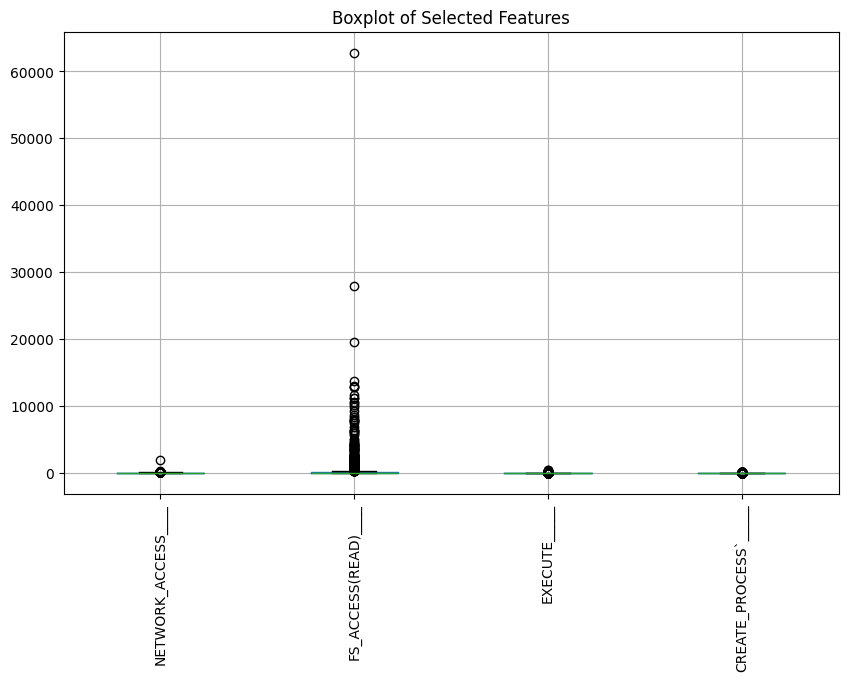

,NETWORK_ACCESS____,FS_ACCESS(READ)____,EXECUTE_____,CREATE_PROCESS`_____
count,11598.000000,11598.000000,11598.00000,11598.000000
mean,5.401621,229.651319,2.25125,0.983877
std,19.466439,886.719497,9.86903,4.061886
min,0.000000,0.000000,0.00000,0.000000
25%,0.000000,10.000000,0.00000,0.000000
50%,0.000000,18.000000,0.00000,0.000000
75%,10.000000,123.000000,0.00000,0.000000
max,1832.000000,62791.000000,399.00000,140.000000


In [14]:
features = ['NETWORK_ACCESS____', 'FS_ACCESS(READ)____', 'EXECUTE_____', 'CREATE_PROCESS`_____']
plt.figure(figsize=(10,6))
df[features].boxplot()
plt.title('Boxplot of Selected Features')
plt.xticks(rotation=90)
plt.show()
display(df[features].describe())

##4.5 PCA 2D Scatter

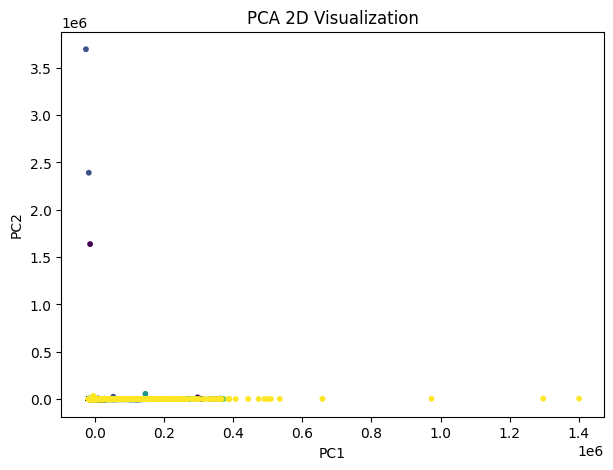

,PC1,PC2,Class
0,-18118.969267,-820.995197,1
1,18945.259542,-567.374851,1
2,-17677.878334,-817.280386,1
3,-8003.808021,-763.833679,1
4,-17826.590342,-817.704195,1
5,-18206.738305,-824.160111,1
6,-18122.290463,-822.392107,1
7,-17377.469283,-794.690330,1
8,-18224.499666,-824.295593,1
9,-16838.844080,-815.165614,1


In [15]:
X = df.drop('Class', axis=1)
pca = PCA(n_components=2)
p = pca.fit_transform(X)
plt.figure(figsize=(7,5))
plt.scatter(p[:,0], p[:,1], c=df['Class'], s=10)
plt.title('PCA 2D Visualization')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()
pca_df = pd.DataFrame(p, columns=['PC1','PC2'])
pca_df['Class'] = df['Class'].values
display(pca_df.head(10))

##4.6 Feature Distribution

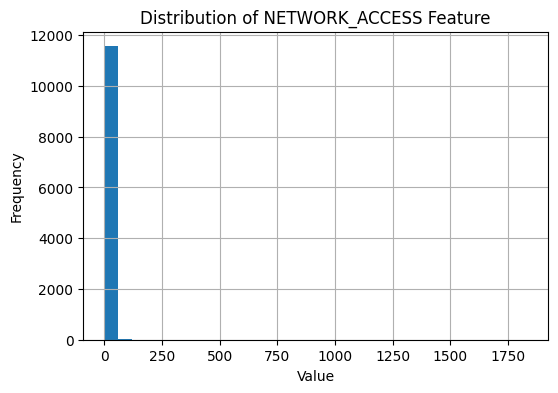

,NETWORK_ACCESS____
count,11598.000000
mean,5.401621
std,19.466439
min,0.000000
25%,0.000000
50%,0.000000
75%,10.000000
max,1832.000000


In [16]:
plt.figure(figsize=(6,4))
df['NETWORK_ACCESS____'].hist(bins=30)
plt.title('Distribution of NETWORK_ACCESS Feature')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()
display(df['NETWORK_ACCESS____'].describe())

#5.Data Pre-processing

##5.1 Check for Missing Values

In [17]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

if not missing_values.empty:
    print("Missing Values Found:")
    print(missing_values)
else:
    print("No missing values found in the dataset.")

No missing values found in the dataset.


##5.2 Check for Duplicate Records

             Type  Count
0  Duplicate Rows     72
1     Unique Rows  11526


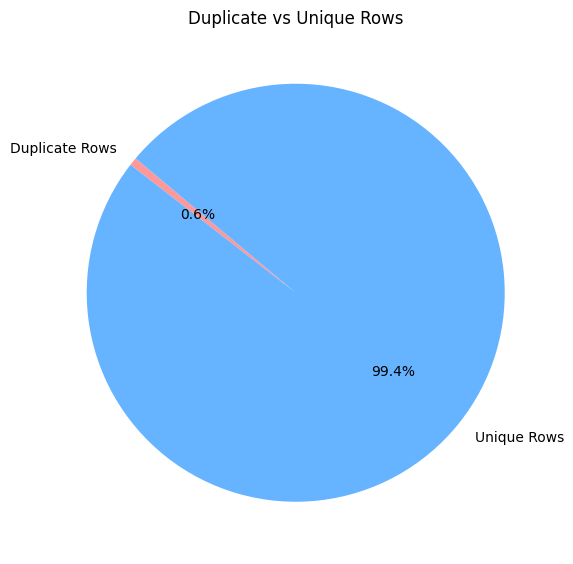

In [18]:
total_duplicates = df.duplicated().sum()
non_duplicates = len(df) - total_duplicates
duplicate_table = pd.DataFrame({
    'Type': ['Duplicate Rows', 'Unique Rows'],
    'Count': [total_duplicates, non_duplicates]
})
print(duplicate_table)

plt.figure(figsize=(6, 6))
plt.pie([total_duplicates, non_duplicates],
        labels=['Duplicate Rows', 'Unique Rows'],
        autopct='%1.1f%%',
        colors=['#ff9999', '#66b3ff'],
        startangle=140)
plt.title("Duplicate vs Unique Rows")
plt.tight_layout()
plt.show()

In [19]:
df = df.drop_duplicates()

total_duplicates_after = df.duplicated().sum()
non_duplicates_after = len(df) - total_duplicates_after

duplicate_table_after = pd.DataFrame({
    'Type': ['Duplicate Rows', 'Unique Rows'],
    'Count': [total_duplicates_after, non_duplicates_after]
})
print("\nAfter removing duplicates:")
print(duplicate_table_after)


After removing duplicates:
             Type  Count
0  Duplicate Rows      0
1     Unique Rows  11526


#6.Feature Engineering

In [20]:
df['Total_FS_Access'] = df[[col for col in df.columns if 'FS_ACCESS' in col]].sum(axis=1)
df['Total_Network_Access'] = df[[col for col in df.columns if 'NETWORK_ACCESS' in col]].sum(axis=1)
df['Total_Process_Thread'] = df[['CREATE_PROCESS`_____', 'CREATE_THREAD_____', 'TERMINATE_PROCESS', 'TERMINATE_THREAD']].sum(axis=1)
df['Total_SMS_Personal'] = df[['SMS_SEND____', 'ACCESS_PERSONAL_INFO___']].sum(axis=1)
df['Average_FS_Access'] = df[[col for col in df.columns if 'FS_ACCESS' in col]].mean(axis=1)
df['Max_Network_Operation'] = df[[col for col in df.columns if 'NETWORK_ACCESS' in col]].max(axis=1)
df['High_Risk_Actions_Flag'] = df[['EXECUTE_____', 'DEVICE_ACCESS_____', 'ANTI_DEBUG_____']].sum(axis=1).apply(lambda x: 1 if x>0 else 0)
df['FS_vs_Network_Ratio'] = df['Total_FS_Access'] / (df['Total_Network_Access'] + 1)
df['Process_Thread_Intensity'] = df['Total_Process_Thread']
df['Overall_Activity_Score'] = df.drop('Class', axis=1).sum(axis=1)

new_columns = ['Total_FS_Access', 'Total_Network_Access', 'Total_Process_Thread', 'Total_SMS_Personal',
               'Average_FS_Access', 'Max_Network_Operation', 'High_Risk_Actions_Flag',
               'FS_vs_Network_Ratio', 'Process_Thread_Intensity', 'Overall_Activity_Score']

display(df[new_columns].head())

,Total_FS_Access,Total_Network_Access,Total_Process_Thread,Total_SMS_Personal,Average_FS_Access,Max_Network_Operation,High_Risk_Actions_Flag,FS_vs_Network_Ratio,Process_Thread_Intensity,Overall_Activity_Score
0,26,7,17,1,2.363636,4,1,3.250000,17,1426.613636
1,210,35,48,3,19.090909,19,1,5.833333,48,74568.924242
2,55,14,35,2,5.000000,10,1,3.666667,35,3687.666667
3,73,3,39,1,6.636364,2,1,18.250000,39,25296.886364
4,57,19,25,3,5.181818,7,1,2.850000,25,3087.031818


#7.Data Splitting: Training, Validation and Test

In [21]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

In [22]:
print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (8068, 480) (8068,)
Validation set: (1729, 480) (1729,)
Test set: (1729, 480) (1729,)



Malware ratio in each set:
Train: 3.1359692612791275
Validation: 3.136495083863505
Test: 3.1359167148640834 



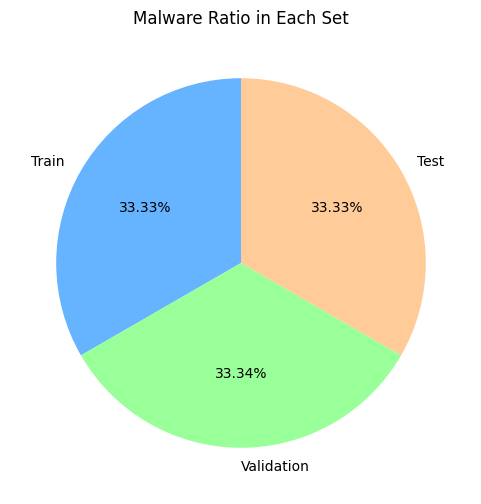

In [23]:
print("\nMalware ratio in each set:")
print("Train:", y_train.mean())
print("Validation:", y_val.mean())
print("Test:", y_test.mean(),"\n")

malware_ratios = {
    "Train": y_train.mean(),
    "Validation": y_val.mean(),
    "Test": y_test.mean()
}

labels = malware_ratios.keys()
sizes = [v * 100 for v in malware_ratios.values()]

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct="%1.2f%%", startangle=90, colors=["#66b3ff","#99ff99","#ffcc99"])
plt.title("Malware Ratio in Each Set")
plt.show()

#8.Data Imbalance

##8.1 Inspect Class Distribution (Before SMOTE)

In [24]:
print("Class distribution in training set (before SMOTE):\n")
print(y_train.value_counts(),"\n")

Class distribution in training set (before SMOTE):

Class
3    2732
4    1774
2    1431
5    1254
1     877
Name: count, dtype: int64 



##8.2 Applying SMOTE on Training Set

In [25]:
X_train_res, y_train_res = SMOTE(random_state=42).fit_resample(X_train, y_train)
print(pd.Series(y_train_res).value_counts())

Class
4    2732
2    2732
1    2732
5    2732
3    2732
Name: count, dtype: int64


/tmp/ipython-input-3664159921.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=before_smote.index, y=before_smote.values, palette='Blues_d')
/tmp/ipython-input-3664159921.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(after_smote.keys()), y=list(after_smote.values()), palette='Greens_d')


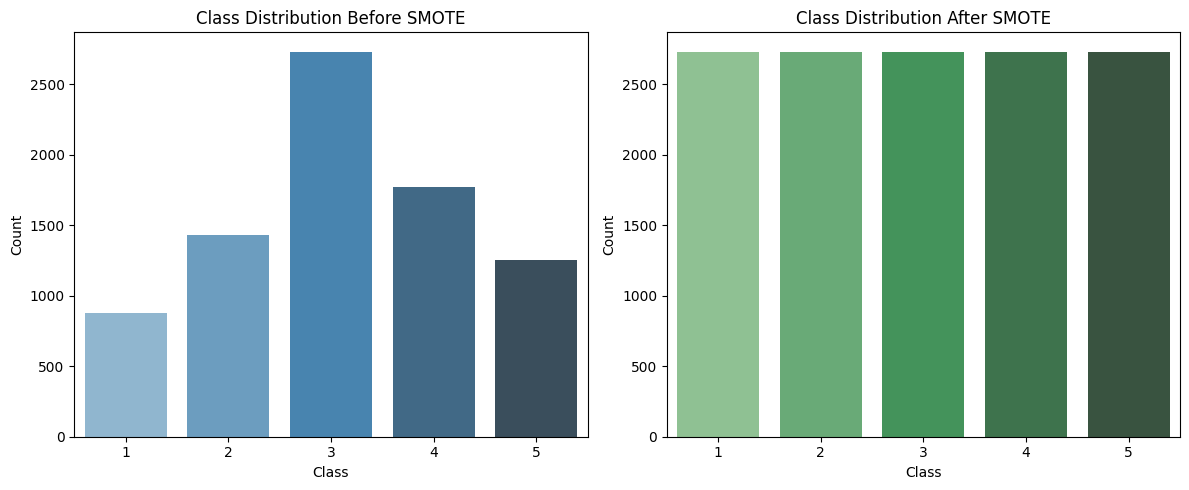

In [26]:
before_smote = y_train.value_counts().sort_index()

after_smote = Counter(y_train_res)

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
sns.barplot(x=before_smote.index, y=before_smote.values, palette='Blues_d')
plt.title('Class Distribution Before SMOTE')
plt.xlabel('Class')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.barplot(x=list(after_smote.keys()), y=list(after_smote.values()), palette='Greens_d')
plt.title('Class Distribution After SMOTE')
plt.xlabel('Class')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

##8.3 Confirm Balanced Distribution

In [27]:
print("Final shape of X_train_resampled:", X_train_res.shape)
print("Final shape of y_train_resampled:", y_train_res.shape)

Final shape of X_train_resampled: (13660, 480)
Final shape of y_train_resampled: (13660,)


#9.Feature Selection

##9.1 Extract Feature Importances

In [28]:
y_train_res_adjusted = y_train_res - 1

lgb_model = LGBMClassifier(random_state=42)
lgb_model.fit(X_train_res, y_train_res_adjusted)

feature_importances = pd.DataFrame({
    "Feature": X_train_res.columns,
    "Importance": lgb_model.feature_importances_
})

importance_threshold = feature_importances["Importance"].mean()
top_features = feature_importances[feature_importances["Importance"] >= importance_threshold]["Feature"]

print("Number of selected top features:", len(top_features))
print("Top features:\n", top_features.tolist())

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.035426 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 22736
[LightGBM] [Info] Number of data points in the train set: 13660, number of used features: 309
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
Number of selected top features: 119
Top features:
 ['ACCESS_PERSONAL_INFO___', 'CREATE_FOLDER_____', 'CREATE_THREAD_____', 'DEVICE_ACCESS_____', 'FS_ACCESS____', 'FS_ACCESS()____', 'FS_ACCESS(CREATE)____', 'FS_ACCESS(CREATE__READ__WRITE)', 'FS_ACCESS(CREATE__WRITE)__', 'FS_ACCESS(READ)____', 'FS_ACCESS(WRITE)____', 'FS_PIPE_ACCESS___', 'FS_PIPE_ACCESS(READ__WRITE)_', 'NET

##9.2 Select Top Important Features

In [29]:
top_features_list = top_features.tolist()

X_train_top = X_train_res[top_features_list]
X_val_top = X_val[top_features_list]
X_test_top = X_test[top_features_list]

print("Shapes after selecting top features:")
print("X_train_top:", X_train_top.shape)
print("X_val_top:", X_val_top.shape)
print("X_test_top:", X_test_top.shape)

Shapes after selecting top features:
X_train_top: (13660, 119)
X_val_top: (1729, 119)
X_test_top: (1729, 119)


#10.Model Training and Evaluation

##10.1 Define All Models (Baseline + Advanced + Ensemble)

In [30]:
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier

baseline_models = {
    "LogisticRegression": LogisticRegression(
        max_iter=300,
        n_jobs=-1,
        multi_class="auto"
    ),
    "GaussianNB": GaussianNB(),
    "LinearSVM": LinearSVC(
        max_iter=100,
        dual=False,
        random_state=42
    )
}

advanced_models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=120,
        max_depth=20,
        min_samples_split=10,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=120,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        eval_metric="mlogloss",
        n_jobs=-1,
        random_state=42
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=150,
        max_depth=-1,
        learning_rate=0.1,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        alpha=0.0005,
        batch_size=256,
        max_iter=120,
        random_state=42
    )
}

ensemble_models = {
    "Voting": VotingClassifier(
        estimators=[
            ("rf", advanced_models["RandomForest"]),
            ("lgbm", advanced_models["LightGBM"]),
            ("mlp", advanced_models["MLP"])
        ],
        voting="soft",
        n_jobs=-1
    ),
    "Stacking": StackingClassifier(
        estimators=[
            ("rf", advanced_models["RandomForest"]),
            ("lgbm", advanced_models["LightGBM"]),
            ("mlp", advanced_models["MLP"])
        ],
        final_estimator=LogisticRegression(max_iter=300),
        n_jobs=-1
    )
}

all_models = {
    "Baseline Models": list(baseline_models.keys()),
    "Advanced Models": list(advanced_models.keys()),
    "Ensemble Models": list(ensemble_models.keys())
}

for category, models in all_models.items():
    print(f"\n{category}:")
    for m in models:
        print("-", m)



Baseline Models:
- LogisticRegression
- GaussianNB
- LinearSVM

Advanced Models:
- RandomForest
- XGBoost
- LightGBM
- MLP

Ensemble Models:
- Voting
- Stacking


##10.2 Model Evaluation Function (Validation Metrics + Confusion Matrix)

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluate_model(model, X_train, y_train, X_val, y_val, model_name):
    print(f"\n--- Evaluating Model: {model_name} ---")
    print("Metrics defined for evaluation:")
    print("- Accuracy: overall correctness of predictions")
    print("- Precision (weighted): correctness of positive predictions across all classes")
    print("- Recall (weighted): ability to find all positive instances across all classes")
    print("- F1-score (weighted): harmonic mean of precision and recall")
    print("- Confusion Matrix: detailed class-wise performance\n")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    if model_name == "XGBoost":
        y_pred = y_pred + 1

    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average="weighted")
    rec = recall_score(y_val, y_pred, average="weighted")
    f1 = f1_score(y_val, y_pred, average="weighted")

    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-score: {f1:.4f}")

    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1_Score": f1
    }



##10.3 Model Training on Top Features Dataset

In [34]:
y_train_xgb = np.array(y_train_res) - 1
y_val_xgb = np.array(y_val) - 1

trained_models_final = {}

for name, model in {**baseline_models, **advanced_models, **ensemble_models}.items():
    print(f"Training model: {name} ...")

    if name == "XGBoost":
        model.fit(X_train_top, y_train_xgb)
    else:
        model.fit(X_train_top, y_train_res)

    trained_models_final[name] = model
    print(f"Model {name} trained successfully.\n")

print("All Models Trained on Top Features Dataset")


Training model: LogisticRegression ...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Model LogisticRegression trained successfully.

Training model: GaussianNB ...
Model GaussianNB trained successfully.

Training model: LinearSVM ...


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Model LinearSVM trained successfully.

Training model: RandomForest ...
Model RandomForest trained successfully.

Training model: XGBoost ...
Model XGBoost trained successfully.

Training model: LightGBM ...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.027325 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 18435
[LightGBM] [Info] Number of data points in the train set: 13660, number of used features: 119
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
Model LightGBM trained successfully.

Training model: MLP ...
Model MLP trained successfully.

Training model: Voting ...
Model Voting trained successfully.

Training model: Stacking ...
Model Stacking trained successfully.

All Mo

##10.4 Evaluation of Trained Models on Validation Set


In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Evaluation Metrics of Trained Models on Validation Set\n")

all_results = []

for name, model in trained_models_final.items():
    if name == "XGBoost":
        y_val_eval = np.array(y_val) - 1
        y_pred = model.predict(X_val_top) + 1
    else:
        y_val_eval = y_val
        y_pred = model.predict(X_val_top)

    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average="weighted")
    rec = recall_score(y_val, y_pred, average="weighted")
    f1 = f1_score(y_val, y_pred, average="weighted")

    all_results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1_Score": f1
    })

results_df = pd.DataFrame(all_results).sort_values(by="F1_Score", ascending=False)
print("Model Comparison on Validation Set")
display(results_df)


Evaluation Metrics of Trained Models on Validation Set

Model Comparison on Validation Set


,Model,Accuracy,Precision,Recall,F1_Score
5,LightGBM,0.955466,0.956097,0.955466,0.955534
8,Stacking,0.954309,0.954520,0.954309,0.954295
4,XGBoost,0.948525,0.949990,0.948525,0.948831
7,Voting,0.942741,0.945830,0.942741,0.943108
3,RandomForest,0.936379,0.938508,0.936379,0.936755
6,MLP,0.803933,0.816417,0.803933,0.800667
1,GaussianNB,0.535570,0.575348,0.535570,0.490601
0,LogisticRegression,0.469057,0.569248,0.469057,0.478379
2,LinearSVM,0.450549,0.576580,0.450549,0.461247


##10.5 Confusion Matrices for Each Model

Confusion Matrices for Each Model



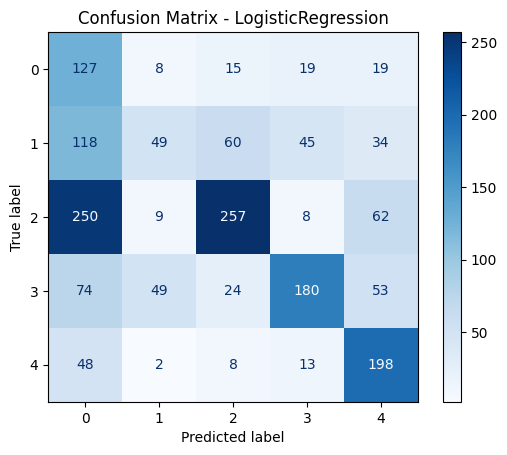

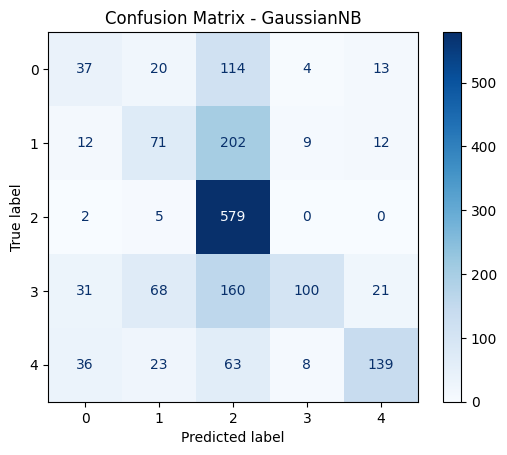

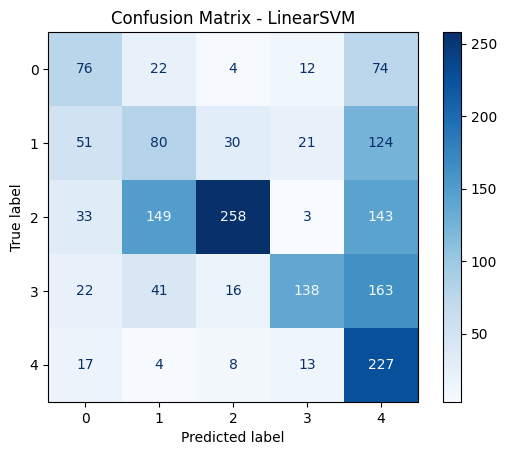

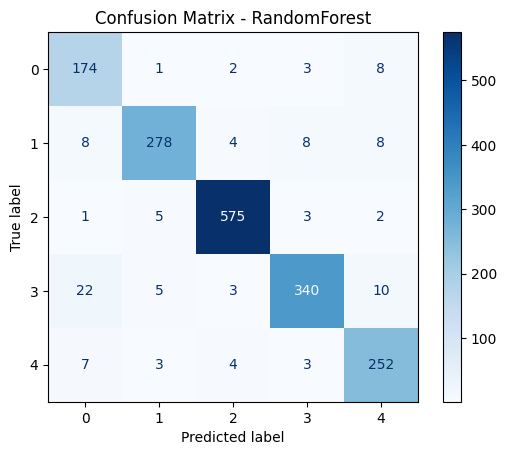

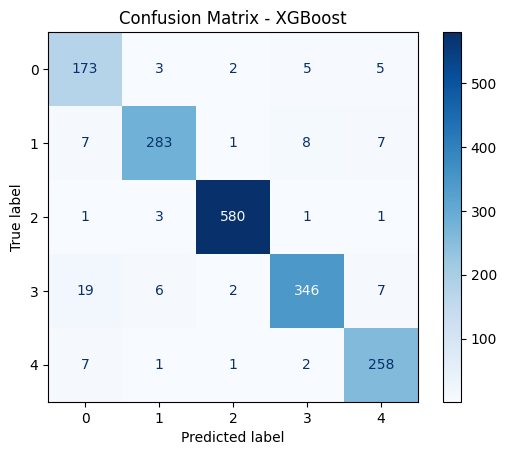

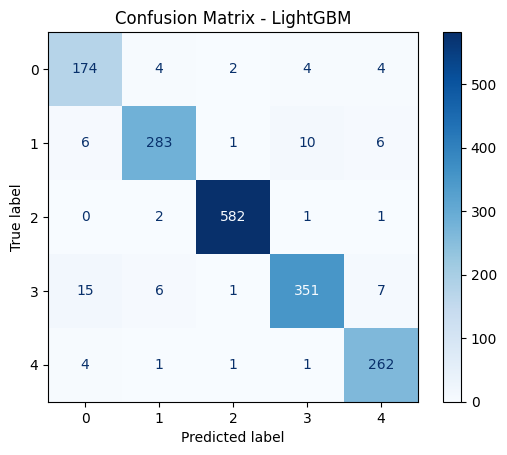

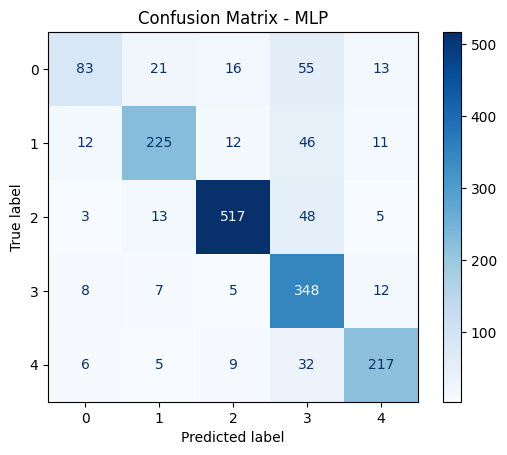

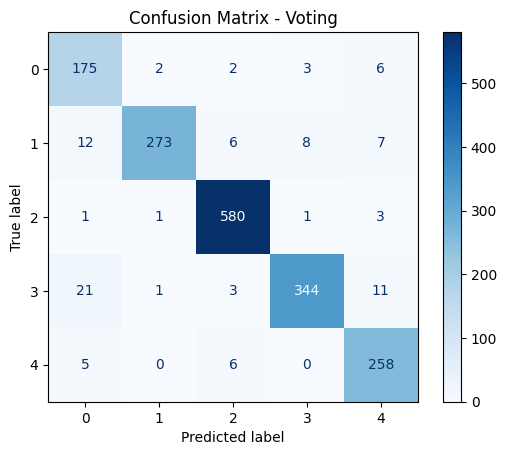

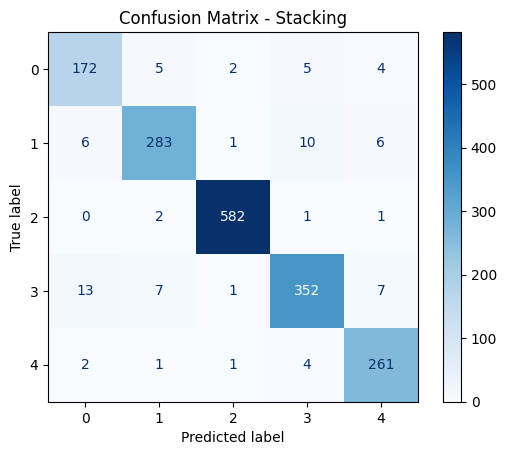

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("Confusion Matrices for Each Model\n")

for name, model in trained_models_final.items():
    if name == "XGBoost":
        y_val_eval = np.array(y_val) - 1
        y_pred = model.predict(X_val_top) + 1
    else:
        y_val_eval = y_val
        y_pred = model.predict(X_val_top)

    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()


#11.K-Fold Cross-Validation for All Models

##11.1 Applying K-Fold Cross-Validation and Showing Metrics Table

In [37]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB


baseline_models = {
    "LogisticRegression": LogisticRegression(max_iter=200, n_jobs=-1, random_state=42),
    "GaussianNB": GaussianNB(),
    "LinearSVM": LinearSVC(max_iter=500, dual=False, random_state=42)
}

advanced_models = {
    "RandomForest": RandomForestClassifier(n_estimators=50, max_depth=20, min_samples_split=10, min_samples_leaf=5, n_jobs=-1, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=50, max_depth=6, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, objective="multi:softprob", eval_metric="mlogloss", n_jobs=-1, random_state=42, verbosity=0),
    "LightGBM": LGBMClassifier(n_estimators=50, max_depth=-1, learning_rate=0.1, num_leaves=31, subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1),
    "MLP": MLPClassifier(hidden_layer_sizes=(128, 64), activation="relu", solver="adam", alpha=0.0005, batch_size=256, max_iter=50, random_state=42)
}

ensemble_models = {
    "Voting": VotingClassifier(
        estimators=[
            ("rf", advanced_models["RandomForest"]),
            ("lgbm", advanced_models["LightGBM"]),
            ("mlp", advanced_models["MLP"])
        ],
        voting="soft",
        n_jobs=-1
    ),
    "Stacking": StackingClassifier(
        estimators=[
            ("rf", advanced_models["RandomForest"]),
            ("lgbm", advanced_models["LightGBM"]),
            ("mlp", advanced_models["MLP"])
        ],
        final_estimator=LogisticRegression(max_iter=200),
        n_jobs=-1
    )
}

trained_models = {**baseline_models, **advanced_models, **ensemble_models}

print("K-Fold Cross-Validation on Top Features Dataset\n")

kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_results = []

for name, model in trained_models.items():
    acc_list, prec_list, rec_list, f1_list = [], [], [], []

    for train_index, val_index in kf.split(X_train_top, y_train_res):
        X_train_fold, X_val_fold = X_train_top.iloc[train_index], X_train_top.iloc[val_index]
        y_train_fold, y_val_fold = y_train_res.iloc[train_index], y_train_res.iloc[val_index]

        if name == "XGBoost":
            y_train_fold_adj = y_train_fold - 1
            model.fit(X_train_fold, y_train_fold_adj)
            y_pred = model.predict(X_val_fold) + 1
        else:
            model.fit(X_train_fold, y_train_fold)
            y_pred = model.predict(X_val_fold)

        acc_list.append(accuracy_score(y_val_fold, y_pred))
        prec_list.append(precision_score(y_val_fold, y_pred, average="weighted"))
        rec_list.append(recall_score(y_val_fold, y_pred, average="weighted"))
        f1_list.append(f1_score(y_val_fold, y_pred, average="weighted"))

    cv_results.append({
        "Model": name,
        "Accuracy": np.mean(acc_list),
        "Precision": np.mean(prec_list),
        "Recall": np.mean(rec_list),
        "F1_Score": np.mean(f1_list)
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(by="F1_Score", ascending=False)
print("Cross-Validation Results (Averaged Across Folds)")
display(cv_results_df)


K-Fold Cross-Validation on Top Features Dataset



/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Cross-Validation Results (Averaged Across Folds)


,Model,Accuracy,Precision,Recall,F1_Score
5,LightGBM,0.959663,0.960037,0.959663,0.959634
8,Stacking,0.959517,0.959678,0.959517,0.959491
4,XGBoost,0.943558,0.944162,0.943558,0.943481
3,RandomForest,0.941948,0.943280,0.941948,0.941912
7,Voting,0.939019,0.940157,0.939019,0.938982
6,MLP,0.712808,0.756993,0.712808,0.703152
2,LinearSVM,0.560320,0.635300,0.560320,0.553839
0,LogisticRegression,0.502123,0.550759,0.502123,0.474839
1,GaussianNB,0.454685,0.567266,0.454685,0.437455


##11.2 Bar Chart Comparison of Models Across Metrics

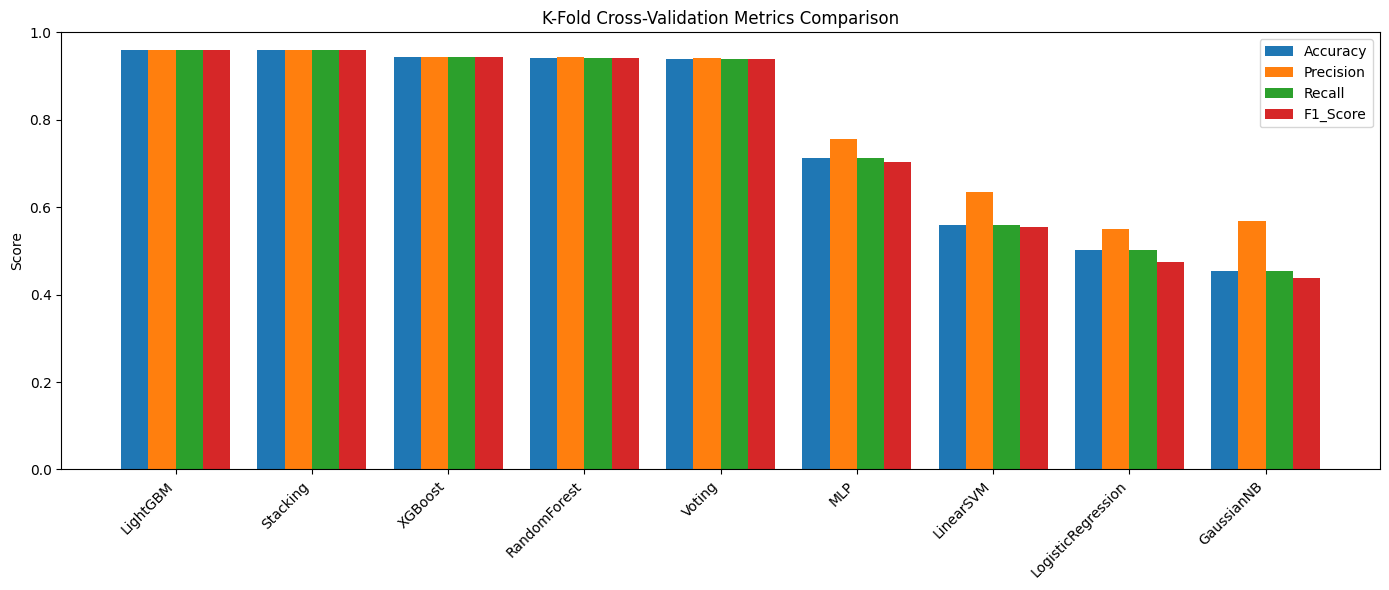

In [39]:
metrics = ["Accuracy", "Precision", "Recall", "F1_Score"]
models = cv_results_df["Model"].tolist()
x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(14,6))

for i, metric in enumerate(metrics):
    plt.bar(x + i*width, cv_results_df[metric], width=width, label=metric)

plt.xticks(x + width*1.5, models, rotation=45, ha="right")
plt.ylabel("Score")
plt.title("K-Fold Cross-Validation Metrics Comparison")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()


##11.3 Top 3 Models Based on F1-Score

In [40]:
top_3_models = cv_results_df.head(3)
print("Top 3 Models Based on F1-Score")
display(top_3_models)


Top 3 Models Based on F1-Score


,Model,Accuracy,Precision,Recall,F1_Score
5,LightGBM,0.959663,0.960037,0.959663,0.959634
8,Stacking,0.959517,0.959678,0.959517,0.959491
4,XGBoost,0.943558,0.944162,0.943558,0.943481


# 12.Hyperparameter Tuning on the Top 3 Models from K-Fold Cross-Validation

##12.1 Defining Parameter Grids

In [45]:
lgbm_param_grid = {
    "num_leaves": [31, 50],
    "max_depth": [-1, 10],
    "learning_rate": [0.05, 0.1],
    "n_estimators": [50, 100]
}

xgb_param_grid = {
    "max_depth": [3, 6],
    "learning_rate": [0.05, 0.1],
    "n_estimators": [50, 100],
    "subsample": [0.8],
    "colsample_bytree": [0.8]
}

stacking_param_grid = {
    "final_estimator__C": [0.1, 1],
    "final_estimator__solver": ["lbfgs"]
}

##12.2 Initializing Models

In [49]:
lgbm_model = LGBMClassifier(random_state=42)
xgb_model = XGBClassifier(objective="multi:softprob", eval_metric="mlogloss",
                          n_jobs=-1, random_state=42, verbosity=0)
stacking_model = StackingClassifier(
    estimators=[
        ("rf", RandomForestClassifier(n_estimators=5, random_state=42)),
        ("lgbm", LGBMClassifier(n_estimators=50, random_state=42)),
        ("mlp", MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=5, random_state=42))
    ],
    final_estimator=LogisticRegression(max_iter=5),
    n_jobs=-1
)


##12.3 Running Hyperparameter Tuning

In [50]:
cv_folds = 3

y_train_xgb = np.array(y_train_res) - 1

lgbm_grid = GridSearchCV(lgbm_model, lgbm_param_grid, scoring="f1_weighted", cv=cv_folds, n_jobs=-1, verbose=1)
xgb_grid = GridSearchCV(xgb_model, xgb_param_grid, scoring="f1_weighted", cv=cv_folds, n_jobs=-1, verbose=1)
stacking_grid = GridSearchCV(stacking_model, stacking_param_grid, scoring="f1_weighted", cv=cv_folds, n_jobs=-1, verbose=1)

print("Tuning LightGBM...")
lgbm_grid.fit(X_train_top, y_train_res)
print(f"Best LightGBM Params: {lgbm_grid.best_params_}")
print(f"Best LightGBM F1-Score: {lgbm_grid.best_score_:.4f}\n")

print("Tuning XGBoost...")
xgb_grid.fit(X_train_top, y_train_xgb)
print(f"Best XGBoost Params: {xgb_grid.best_params_}")
print(f"Best XGBoost F1-Score: {xgb_grid.best_score_:.4f}\n")

print("Tuning Stacking...")
stacking_grid.fit(X_train_top, y_train_res)
print(f"Best Stacking Params: {stacking_grid.best_params_}")
print(f"Best Stacking F1-Score: {stacking_grid.best_score_:.4f}\n")



Tuning LightGBM...
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best LightGBM Params: {'learning_rate': 0.1, 'max_depth': -1, 'n_estimators': 100, 'num_leaves': 31}
Best LightGBM F1-Score: 0.9679

Tuning XGBoost...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best XGBoost Params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100, 'subsample': 0.8}
Best XGBoost F1-Score: 0.9570

Tuning Stacking...
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Best Stacking Params: {'final_estimator__C': 0.1, 'final_estimator__solver': 'lbfgs'}
Best Stacking F1-Score: 0.9590



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


##12.4 Hyperparameter Tuning Results

In [51]:
tuning_results = pd.DataFrame({
    "Model": ["LightGBM", "XGBoost", "Stacking"],
    "Best Parameters": [
        lgbm_grid.best_params_,
        xgb_grid.best_params_,
        stacking_grid.best_params_
    ],
    "Best F1_Score": [
        lgbm_grid.best_score_,
        xgb_grid.best_score_,
        stacking_grid.best_score_
    ]
})

display(tuning_results)


,Model,Best Parameters,Best F1_Score
0,LightGBM,"{'learning_rate': 0.1, 'max_depth': -1, 'n_est...",0.967883
1,XGBoost,"{'colsample_bytree': 0.8, 'learning_rate': 0.1...",0.956957
2,Stacking,"{'final_estimator__C': 0.1, 'final_estimator__...",0.958967


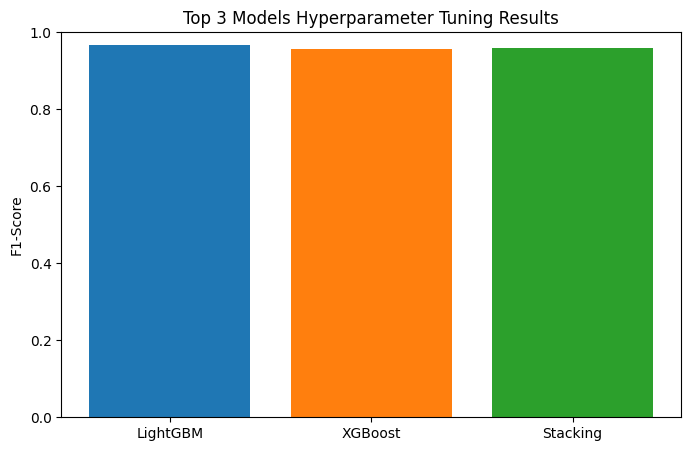

In [52]:
plt.figure(figsize=(8,5))
plt.bar(tuning_results["Model"], tuning_results["Best F1_Score"], color=["#1f77b4", "#ff7f0e", "#2ca02c"])
plt.ylim(0, 1)
plt.ylabel("F1-Score")
plt.title("Top 3 Models Hyperparameter Tuning Results")
plt.show()



#13.Model Performance Comparisons with Statistical Significance

##13.1 Build Best Models After Hyperparameter Tuning

In [56]:
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

best_lgbm = LGBMClassifier(**lgbm_grid.best_params_, random_state=42)

best_xgb = XGBClassifier(
    **xgb_grid.best_params_,
    objective="multi:softprob",
    eval_metric="mlogloss",
    n_jobs=-1,
    random_state=42,
    verbosity=0
)

stacking_final_estimator_params = {}
for k, v in stacking_grid.best_params_.items():
    if k.startswith("final_estimator__"):
        param_name = k.replace("final_estimator__", "")
        stacking_final_estimator_params[param_name] = v

best_stacking = StackingClassifier(
    estimators=[
        ("rf", RandomForestClassifier(n_estimators=50, random_state=42)),
        ("lgbm", LGBMClassifier(n_estimators=50, random_state=42)),
        ("mlp", MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=50, random_state=42))
    ],
    final_estimator=LogisticRegression(**stacking_final_estimator_params),
    n_jobs=-1
)

tuned_models = {
    "LightGBM": best_lgbm,
    "XGBoost": best_xgb,
    "Stacking": best_stacking
}

print("Tuned top 3 models built successfully!")


Tuned top 3 models built successfully!


##13.2 Evaluate Tuned Top 3 Models on Test Set

In [57]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Evaluating Tuned Top 3 Models on Test Set\n")

tuned_results = []

for name, model in tuned_models.items():
    print(f"Training and evaluating model: {name} ...")

    if name == "XGBoost":
        y_train_adj = np.array(y_train_res) - 1
        y_test_adj = np.array(y_test) - 1
        model.fit(X_train_top, y_train_adj)
        y_pred = model.predict(X_test_top) + 1
    else:
        model.fit(X_train_top, y_train_res)
        y_pred = model.predict(X_test_top)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted")
    rec = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    print(f"{name} -> Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1-score: {f1:.4f}\n")

    tuned_results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1_Score": f1
    })

tuned_results_df = pd.DataFrame(tuned_results).sort_values(by="F1_Score", ascending=False)
print("Performance of Tuned Models on Test Set")
display(tuned_results_df)


Evaluating Tuned Top 3 Models on Test Set

Training and evaluating model: LightGBM ...
LightGBM -> Accuracy: 0.9584, Precision: 0.9585, Recall: 0.9584, F1-score: 0.9584

Training and evaluating model: XGBoost ...
XGBoost -> Accuracy: 0.9526, Precision: 0.9532, Recall: 0.9526, F1-score: 0.9527

Training and evaluating model: Stacking ...
Stacking -> Accuracy: 0.9543, Precision: 0.9544, Recall: 0.9543, F1-score: 0.9543

Performance of Tuned Models on Test Set


,Model,Accuracy,Precision,Recall,F1_Score
0,LightGBM,0.958357,0.958483,0.958357,0.958353
2,Stacking,0.954309,0.954434,0.954309,0.954284
1,XGBoost,0.952574,0.953181,0.952574,0.952708


##13.3 Model Performance on Test Set after Hyperparameter Tuning

Tuned Top 3 Models Performance on Test Set


,Model,Accuracy,Precision,Recall,F1_Score
0,LightGBM,0.958357,0.958483,0.958357,0.958353
2,Stacking,0.954309,0.954434,0.954309,0.954284
1,XGBoost,0.952574,0.953181,0.952574,0.952708


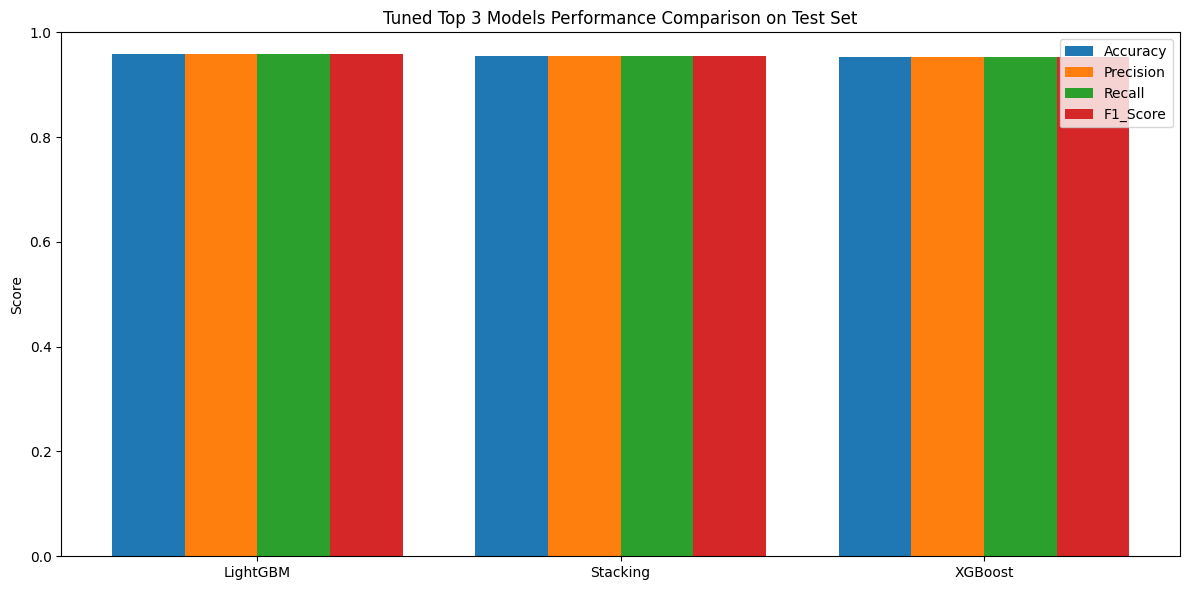

In [58]:
print("Tuned Top 3 Models Performance on Test Set")
display(tuned_results_df)

metrics = ["Accuracy", "Precision", "Recall", "F1_Score"]
x = np.arange(len(tuned_results_df["Model"]))
width = 0.2

plt.figure(figsize=(12,6))

for i, metric in enumerate(metrics):
    plt.bar(x + i*width, tuned_results_df[metric], width=width, label=metric)

plt.xticks(x + width*1.5, tuned_results_df["Model"], rotation=0)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Tuned Top 3 Models Performance Comparison on Test Set")
plt.legend()
plt.tight_layout()
plt.show()


##13.4 Statistical Significance Tests

In [62]:
from sklearn.metrics import f1_score
import itertools
from scipy.stats import ttest_rel

y_preds = {}
for name, model in tuned_models.items():
    if name == "XGBoost":
        y_train_adj = np.array(y_train_res) - 1
        y_test_adj = np.array(y_test) - 1
        model.fit(X_train_top, y_train_adj)
        y_pred = model.predict(X_test_top) + 1
    else:
        model.fit(X_train_top, y_train_res)
        y_pred = model.predict(X_test_top)
    y_preds[name] = y_pred

results = []
models = list(tuned_models.keys())

for m1, m2 in itertools.combinations(models, 2):
    f1_per_sample_m1 = (y_test == y_preds[m1]).astype(int)
    f1_per_sample_m2 = (y_test == y_preds[m2]).astype(int)

    t_stat, p_val = ttest_rel(f1_per_sample_m1, f1_per_sample_m2)

    results.append({
        "Model 1": m1,
        "Model 2": m2,
        "Mean Accuracy Model 1": f1_per_sample_m1.mean(),
        "Mean Accuracy Model 2": f1_per_sample_m2.mean(),
        "t-statistic": t_stat,
        "p-value": p_val
    })

significance_df = pd.DataFrame(results)
print("Pairwise Statistical Significance Tests (per-sample accuracy)")
display(significance_df)


Pairwise Statistical Significance Tests (per-sample accuracy)


,Model 1,Model 2,Mean Accuracy Model 1,Mean Accuracy Model 2,t-statistic,p-value
0,LightGBM,XGBoost,0.958357,0.952574,2.043114,0.041193
1,LightGBM,Stacking,0.958357,0.954309,1.606644,0.108315
2,XGBoost,Stacking,0.952574,0.954309,-0.625433,0.531769


#14.Model Performance Visualization

##14.1 ROC Curves of Tuned Models

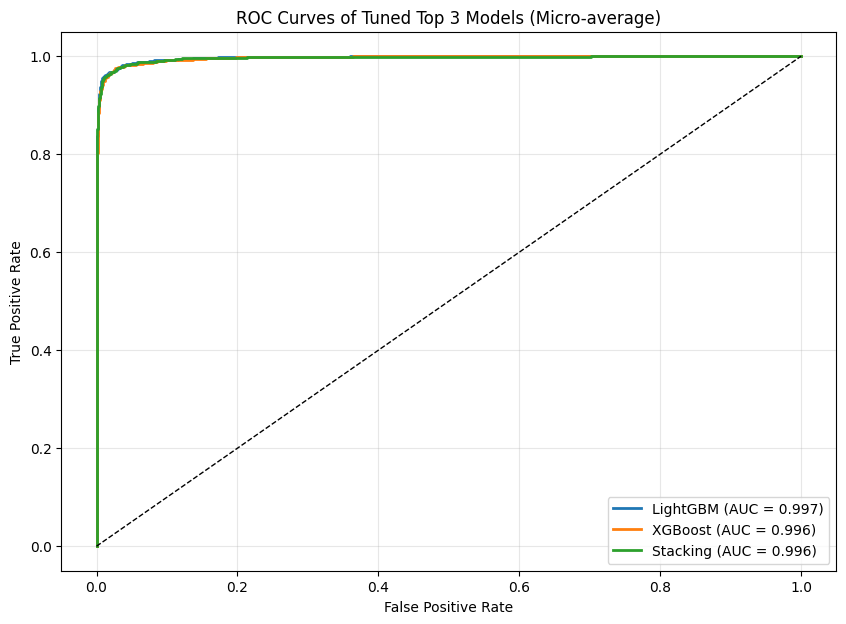

In [63]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(10, 7))

for name, model in tuned_models.items():
    if name == "XGBoost":
        y_train_adj = np.array(y_train_res) - 1
        y_test_adj = np.array(y_test) - 1
        model.fit(X_train_top, y_train_adj)
        y_score = model.predict_proba(X_test_top)
    else:
        model.fit(X_train_top, y_train_res)
        y_score = model.predict_proba(X_test_top)

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    plt.plot(fpr["micro"], tpr["micro"], label=f'{name} (AUC = {roc_auc["micro"]:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves of Tuned Top 3 Models (Micro-average)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


##14.2 Precision–Recall Curves of Tuned Models

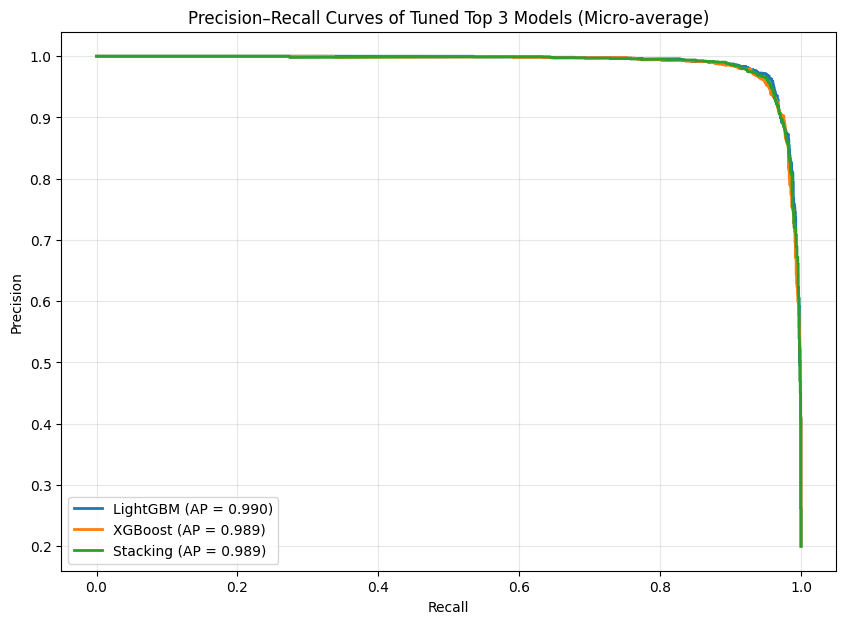

In [64]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10, 7))

for name, model in tuned_models.items():
    if name == "XGBoost":
        y_train_adj = np.array(y_train_res) - 1
        y_test_adj = np.array(y_test) - 1
        model.fit(X_train_top, y_train_adj)
        y_score = model.predict_proba(X_test_top)
    else:
        model.fit(X_train_top, y_train_res)
        y_score = model.predict_proba(X_test_top)

    precision = dict()
    recall = dict()
    ap = dict()

    for i in range(n_classes):
        precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
        ap[i] = average_precision_score(y_test_bin[:, i], y_score[:, i])

    precision["micro"], recall["micro"], _ = precision_recall_curve(y_test_bin.ravel(), y_score.ravel())
    ap["micro"] = average_precision_score(y_test_bin, y_score, average="micro")

    plt.plot(recall["micro"], precision["micro"], label=f'{name} (AP = {ap["micro"]:.3f})', linewidth=2)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves of Tuned Top 3 Models (Micro-average)")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()


#15.Final Best Model with Justification

Based on the evaluation of the top three tuned models on the test set, LightGBM is selected as the final best model. It achieved the highest performance with an accuracy of 0.9584, precision of 0.9585, recall of 0.9584, and an F1-score of 0.9584, outperforming XGBoost (accuracy 0.9526, F1-score 0.9527) and Stacking (accuracy 0.9543, F1-score 0.9543). LightGBM also demonstrated consistent results across K-Fold cross-validation and hyperparameter tuning, making it reliable for generalization. Additionally, it is efficient and scalable, handling high-dimensional data quickly while supporting parallel processing.

Statistical significance testing further supports its superiority, as the paired t-test between LightGBM and XGBoost yielded a t-statistic of 2.0431 with a p-value of 0.0412, indicating a meaningful difference in performance. Considering these factors—high accuracy, F1-score, consistency, efficiency, and statistical significance. LightGBM is the most suitable model for deployment, while XGBoost and Stacking remain strong alternatives if ensemble or diversity in predictions is desired.

# 16.Model Deployment

##16.1 Align feature matrices with label lengths

In [117]:
X_train_top = X_train_res[top_features_list].iloc[:len(y_train)]
X_val_top   = X_val[top_features_list].iloc[:len(y_val)]
X_test_top  = X_test[top_features_list].iloc[:len(y_test)]

print("Shapes after alignment:")
print("X_train_top:", X_train_top.shape, "y_train:", len(y_train))
print("X_val_top:", X_val_top.shape, "y_val:", len(y_val))
print("X_test_top:", X_test_top.shape, "y_test:", len(y_test))

Shapes after alignment:
X_train_top: (8068, 119) y_train: 8068
X_val_top: (1729, 119) y_val: 1729
X_test_top: (1729, 119) y_test: 1729


##16.2 Prepare Data and Encode labels

In [118]:
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras import layers, models, optimizers
from sklearn.metrics import accuracy_score, f1_score

caler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_top)
X_val_scaled   = scaler.transform(X_val_top)
X_test_scaled  = scaler.transform(X_test_top)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_top.columns)
X_val_scaled   = pd.DataFrame(X_val_scaled, columns=X_train_top.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled, columns=X_train_top.columns)

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

print("Unique classes after encoding:", np.unique(y_train_enc))


Unique classes after encoding: [0 1 2 3 4]


##16.3 Teacher predictions and Define Student Model

In [119]:
teacher_preds_train = final_model.predict_proba(X_train_scaled)
teacher_preds_val   = final_model.predict_proba(X_val_scaled)

print("Teacher predictions shape (train):", teacher_preds_train.shape)
print("Teacher predictions shape (val):", teacher_preds_val.shape)

input_shape = X_train_scaled.shape[1]
num_classes = teacher_preds_train.shape[1]

student_model = models.Sequential([
    layers.Input(shape=(input_shape,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

temperature = 3.0
alpha = 0.5

def distillation_loss(y_true, y_pred, teacher_probs, temperature, alpha):
    y_pred_soft = tf.nn.softmax(y_pred / temperature)
    soft_loss = tf.reduce_mean(
        tf.keras.losses.categorical_crossentropy(
            teacher_probs, y_pred_soft
        )
    )
    hard_loss = tf.reduce_mean(
        tf.keras.losses.categorical_crossentropy(y_true, tf.nn.softmax(y_pred))
    )
    return alpha * hard_loss + (1 - alpha) * soft_loss


Teacher predictions shape (train): (8068, 5)
Teacher predictions shape (val): (1729, 5)


##16.4 Prepare one-hot labels and Custom training loop

In [120]:
num_classes = teacher_preds_train.shape[1]

y_train_onehot = tf.keras.utils.to_categorical(y_train_enc, num_classes=num_classes)
y_val_onehot   = tf.keras.utils.to_categorical(y_val_enc, num_classes=num_classes)

input_shape = X_train_scaled.shape[1]

student_model = models.Sequential([
    layers.Input(shape=(input_shape,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

optimizer = optimizers.Adam(learning_rate=0.001)

temperature = 3.0
alpha = 0.5
batch_size = 32
epochs = 30


train_dataset = tf.data.Dataset.from_tensor_slices(
    (X_train_scaled.values, y_train_onehot, teacher_preds_train)
).shuffle(1024).batch(batch_size)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (X_val_scaled.values, y_val_onehot, teacher_preds_val)
).batch(batch_size)

def distillation_loss(y_true, y_pred, teacher_probs, temperature, alpha):
    y_pred_soft = tf.nn.softmax(y_pred / temperature)
    soft_loss = tf.reduce_mean(
        tf.keras.losses.categorical_crossentropy(teacher_probs, y_pred_soft)
    )
    hard_loss = tf.reduce_mean(
        tf.keras.losses.categorical_crossentropy(y_true, tf.nn.softmax(y_pred))
    )
    return alpha * hard_loss + (1 - alpha) * soft_loss

for epoch in range(epochs):
    print(f"Epoch {epoch+1}/{epochs}")
    for step, (x_batch, y_batch, t_batch) in enumerate(train_dataset):
        with tf.GradientTape() as tape:
            logits = student_model(x_batch, training=True)
            loss = distillation_loss(y_batch, logits, t_batch, temperature, alpha)
        grads = tape.gradient(loss, student_model.trainable_variables)
        optimizer.apply_gradients(zip(grads, student_model.trainable_variables))
        if step % 100 == 0:
            print(f"Step {step}, Loss: {loss.numpy():.4f}")


Epoch 1/30
Step 0, Loss: 1.6083
Step 100, Loss: 1.4695
Step 200, Loss: 1.3781
Epoch 2/30
Step 0, Loss: 1.4320
Step 100, Loss: 1.3375
Step 200, Loss: 1.3899
Epoch 3/30
Step 0, Loss: 1.3027
Step 100, Loss: 1.3739
Step 200, Loss: 1.3295
Epoch 4/30
Step 0, Loss: 1.2865
Step 100, Loss: 1.3360
Step 200, Loss: 1.3485
Epoch 5/30
Step 0, Loss: 1.3430
Step 100, Loss: 1.2655
Step 200, Loss: 1.3302
Epoch 6/30
Step 0, Loss: 1.3168
Step 100, Loss: 1.2563
Step 200, Loss: 1.2909
Epoch 7/30
Step 0, Loss: 1.2871
Step 100, Loss: 1.2686
Step 200, Loss: 1.3288
Epoch 8/30
Step 0, Loss: 1.2778
Step 100, Loss: 1.3124
Step 200, Loss: 1.3290
Epoch 9/30
Step 0, Loss: 1.3638
Step 100, Loss: 1.3403
Step 200, Loss: 1.2675
Epoch 10/30
Step 0, Loss: 1.2921
Step 100, Loss: 1.3334
Step 200, Loss: 1.2893
Epoch 11/30
Step 0, Loss: 1.2911
Step 100, Loss: 1.3468
Step 200, Loss: 1.3430
Epoch 12/30
Step 0, Loss: 1.3033
Step 100, Loss: 1.2530
Step 200, Loss: 1.3033
Epoch 13/30
Step 0, Loss: 1.3246
Step 100, Loss: 1.2574
Step 

##16.5 Evaluate on validation set

In [121]:
y_val_preds = []
for x_batch, y_batch, t_batch in val_dataset:
    preds = student_model(x_batch, training=False)
    y_val_preds.append(preds.numpy())
y_val_preds = np.vstack(y_val_preds)
y_val_class = np.argmax(y_val_preds, axis=1)

print("Validation Accuracy:", accuracy_score(y_val_enc, y_val_class))
print("Validation F1-Score:", f1_score(y_val_enc, y_val_class, average='weighted'))


Validation Accuracy: 0.8704453441295547
Validation F1-Score: 0.8688763283800451


##16.6 Convert to TFLite

In [123]:
student_model.save("student_model.h5")
converter = tf.lite.TFLiteConverter.from_keras_model(student_model)
tflite_model = converter.convert()
with open("lgbm_distilled_model.tflite", "wb") as f:
    f.write(tflite_model)
print("Distilled TFLite model saved as 'lgbm_distilled_model.tflite'")



Saved artifact at '/tmp/tmpgi9roebx'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 119), dtype=tf.float32, name='keras_tensor_40')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  138012381601552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138012381601936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138012381595792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138012381601744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138012381602512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138012381602128: TensorSpec(shape=(), dtype=tf.resource, name=None)
Distilled TFLite model saved as 'lgbm_distilled_model.tflite'
